In [10]:

using ImageFiltering

function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end


gaussian_smooth (generic function with 1 method)

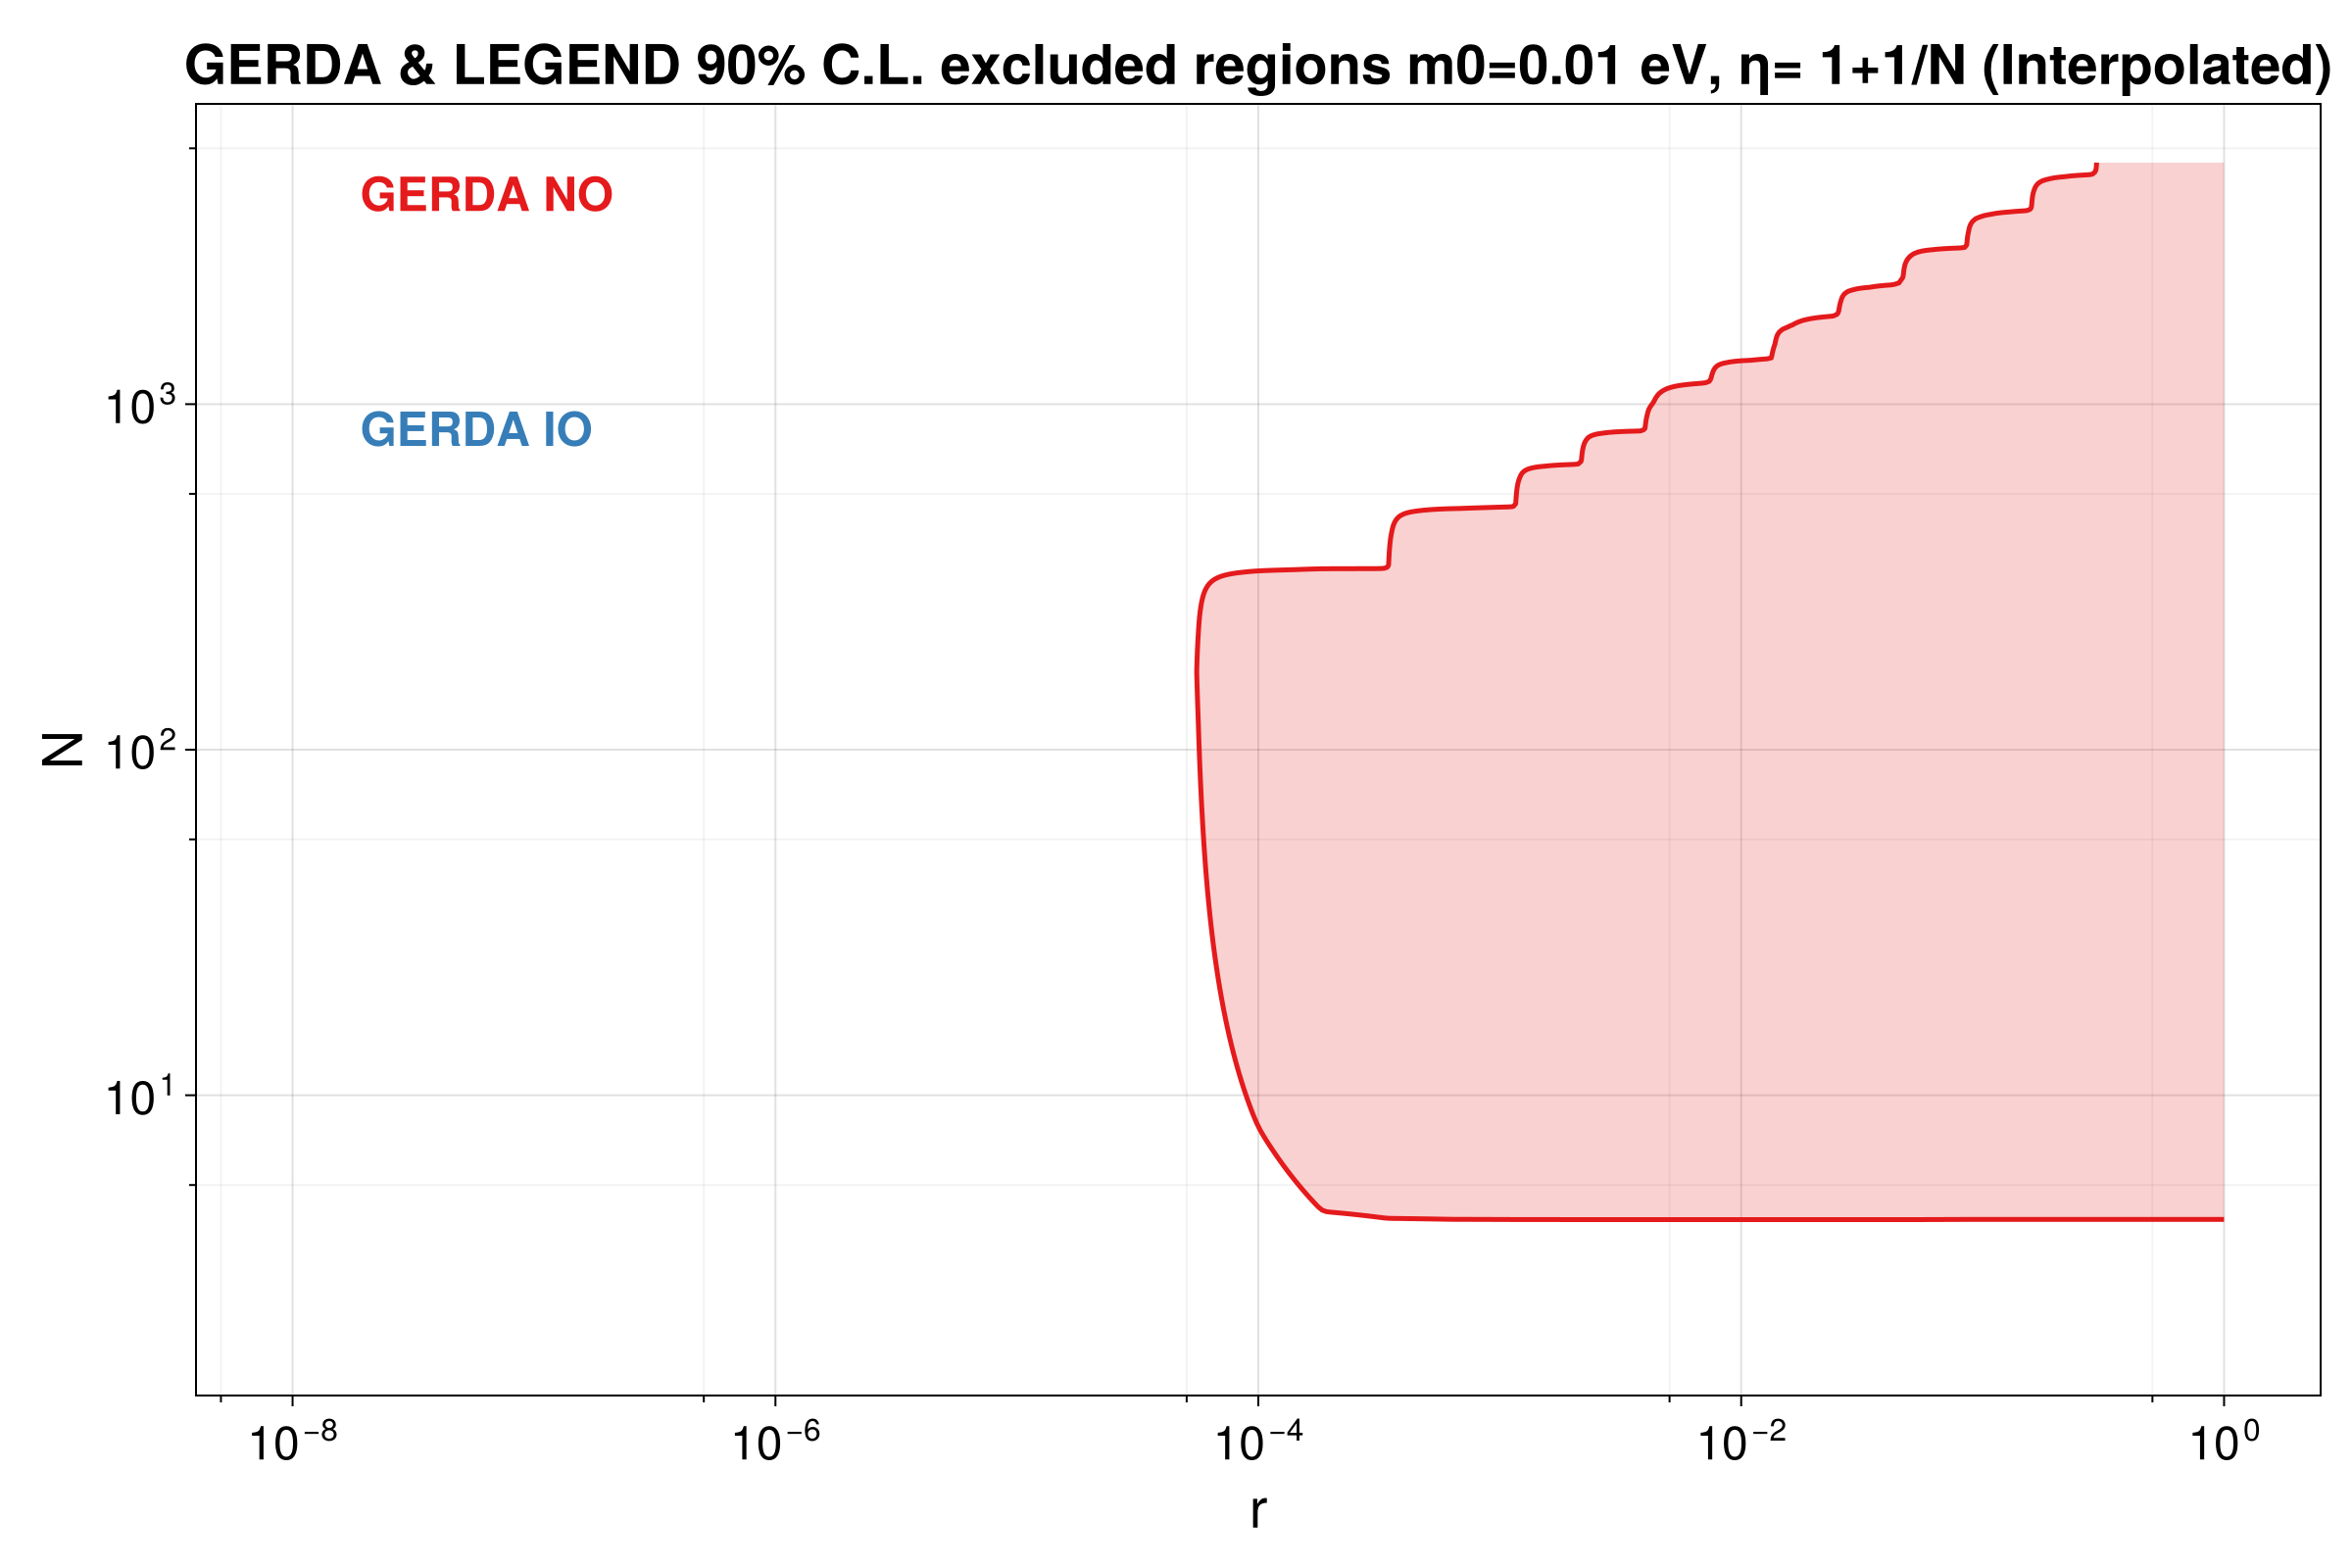

LoadError: UndefVarError: `axis_labels` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos
using Interpolations


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end


function logrange(start::Real, stop::Real, length::Integer)
    """Create a logarithmically spaced range"""
    return 10 .^ range(log10(start), log10(stop), length=length)
end


function interpolate_to_common_grid(result, common_axes)
    """Interpolate result data to a common grid using linear interpolation"""
    itp = linear_interpolation(
        (result.axes[1], result.axes[2]), 
        result.values.log_posterior,
        extrapolation_bc=NaN  # Return NaN outside original range
    )
    return itp.(common_axes[1], common_axes[2]')
end


function pad_to_common_grid(result, common_axes)
    """Place original data at correct locations in common grid, fill gaps with NaN"""
    padded = fill(NaN, length(common_axes[1]), length(common_axes[2]))
    
    # Find indices where original grid overlaps with common grid
    ix = searchsortedfirst(common_axes[1], first(result.axes[1])):searchsortedlast(common_axes[1], last(result.axes[1]))
    iy = searchsortedfirst(common_axes[2], first(result.axes[2])):searchsortedlast(common_axes[2], last(result.axes[2]))
    
    if !isempty(ix) && !isempty(iy)
        padded[ix, iy] = result.values.log_posterior
    end
    return padded
end


function superpose_contours_outside_interpolate(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           xlims=nothing,
                           ylims=nothing,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
    """Uses linear interpolation to map data to common grid"""
 
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    nlabels= length(file_paths)
    if n_colors > length(colors)
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        data = load(file_path)
        result = only(values(data))
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
    
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Automatically use log scale when the axis label contains N and no explicit scale was provided
    if xscale === identity && occursin("N", String(axis_labels[1]))
        xscale = log10
    end
    if yscale === identity && occursin("N", String(axis_labels[2]))
        yscale = log10
    end

    # Create common grid with fine resolution
    n_points_x = 500
    n_points_y = 500
    common_x = if xscale == log10
        logrange(x_min, x_max, n_points_x)
    else
        range(x_min, x_max, length=n_points_x)
    end
    common_y = if yscale == log10
        logrange(y_min, y_max, n_points_y)
    else
        range(y_min, y_max, length=n_points_y)
    end

    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 28,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
        )

    for (idx, result) in enumerate(results)
        # Interpolate to common grid
        log_posterior_interpolated = interpolate_to_common_grid(result, (common_x, common_y))
        dLLH_raw = 2 .* (maximum(skipmissing(vec(log_posterior_interpolated))) .- log_posterior_interpolated)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                common_x,
                common_y,
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        contour!(ax,
            common_x,
            common_y,
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
    end
    
    if experiments !== nothing
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = if nlabels == 1
            [0.95]
        else
            collect(range(0.95, 0.75, length=nlabels))
        end
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.035)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 24,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


function superpose_contours_outside_padded(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           xlims=nothing,
                           ylims=nothing,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
    """Uses padding to place original data at exact locations, no interpolation"""
 
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    nlabels= length(file_paths)
    if n_colors > length(colors)
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        data = load(file_path)
        result = only(values(data))
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
    
    # Create common grid by finding unique points from all axes (preserves original grids)
    common_x = sort(unique(vcat([collect(ax) for ax in all_axes_1]...)))
    common_y = sort(unique(vcat([collect(ax) for ax in all_axes_2]...)))
        
    first_result = results[1]
    # Automatically use log scale when the axis label contains N and no explicit scale was provided
    if xscale === identity && occursin("N", String(axis_labels[1]))
        xscale = log10
    end
    if yscale === identity && occursin("N", String(axis_labels[2]))
        yscale = log10
    end

    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 28,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24,
        xscale = xscale,
        yscale = yscale
        )

    if xlims !== nothing
        ax.xlimits = xlims
    end
    if ylims !== nothing
        ax.ylimits = ylims
    end
        dLLH = smooth_sigma === nothing ? dLLH_raw :
    for (idx, result) in enumerate(results)
        # Pad to common grid
        log_posterior_padded = pad_to_common_grid(result, (common_x, common_y))
        dLLH_raw = 2 .* (maximum(skipmissing(vec(log_posterior_padded))) .- log_posterior_padded)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                common_x,
                common_y,
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        contour!(ax,
            common_x,
            common_y,
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
    end
    
    if experiments !== nothing
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                return min_val + fraction * (max_val - min_val)
            end
        end
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        fractions_y = if nlabels == 1
            [0.95]
        else
            collect(range(0.95, 0.75, length=nlabels))
        end
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.035)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 24,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/scan_final/scan_gerda_rN_m0_0.01_NNM_NO_5000.jld2",
    "/home/sofialon/Newtrinos.jl/plot_auto/gerda/scan_gerda_rN_m0=0.01_NNM_NO.jld2",
            ]

# Try interpolation method
fig_interp = superpose_contours_outside_interpolate(file_paths;  
    title="GERDA & LEGEND 90% C.L. excluded regions m0=0.01 eV, η= 1+1/N (Interpolated)",
    experiments = ["GERDA NO", "GERDA IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    yscale=log10,
    smooth_sigma=0.8)
    experiments = ["GERDA NO", "GERDA IO"], 
display("image/png", fig_interp)





 

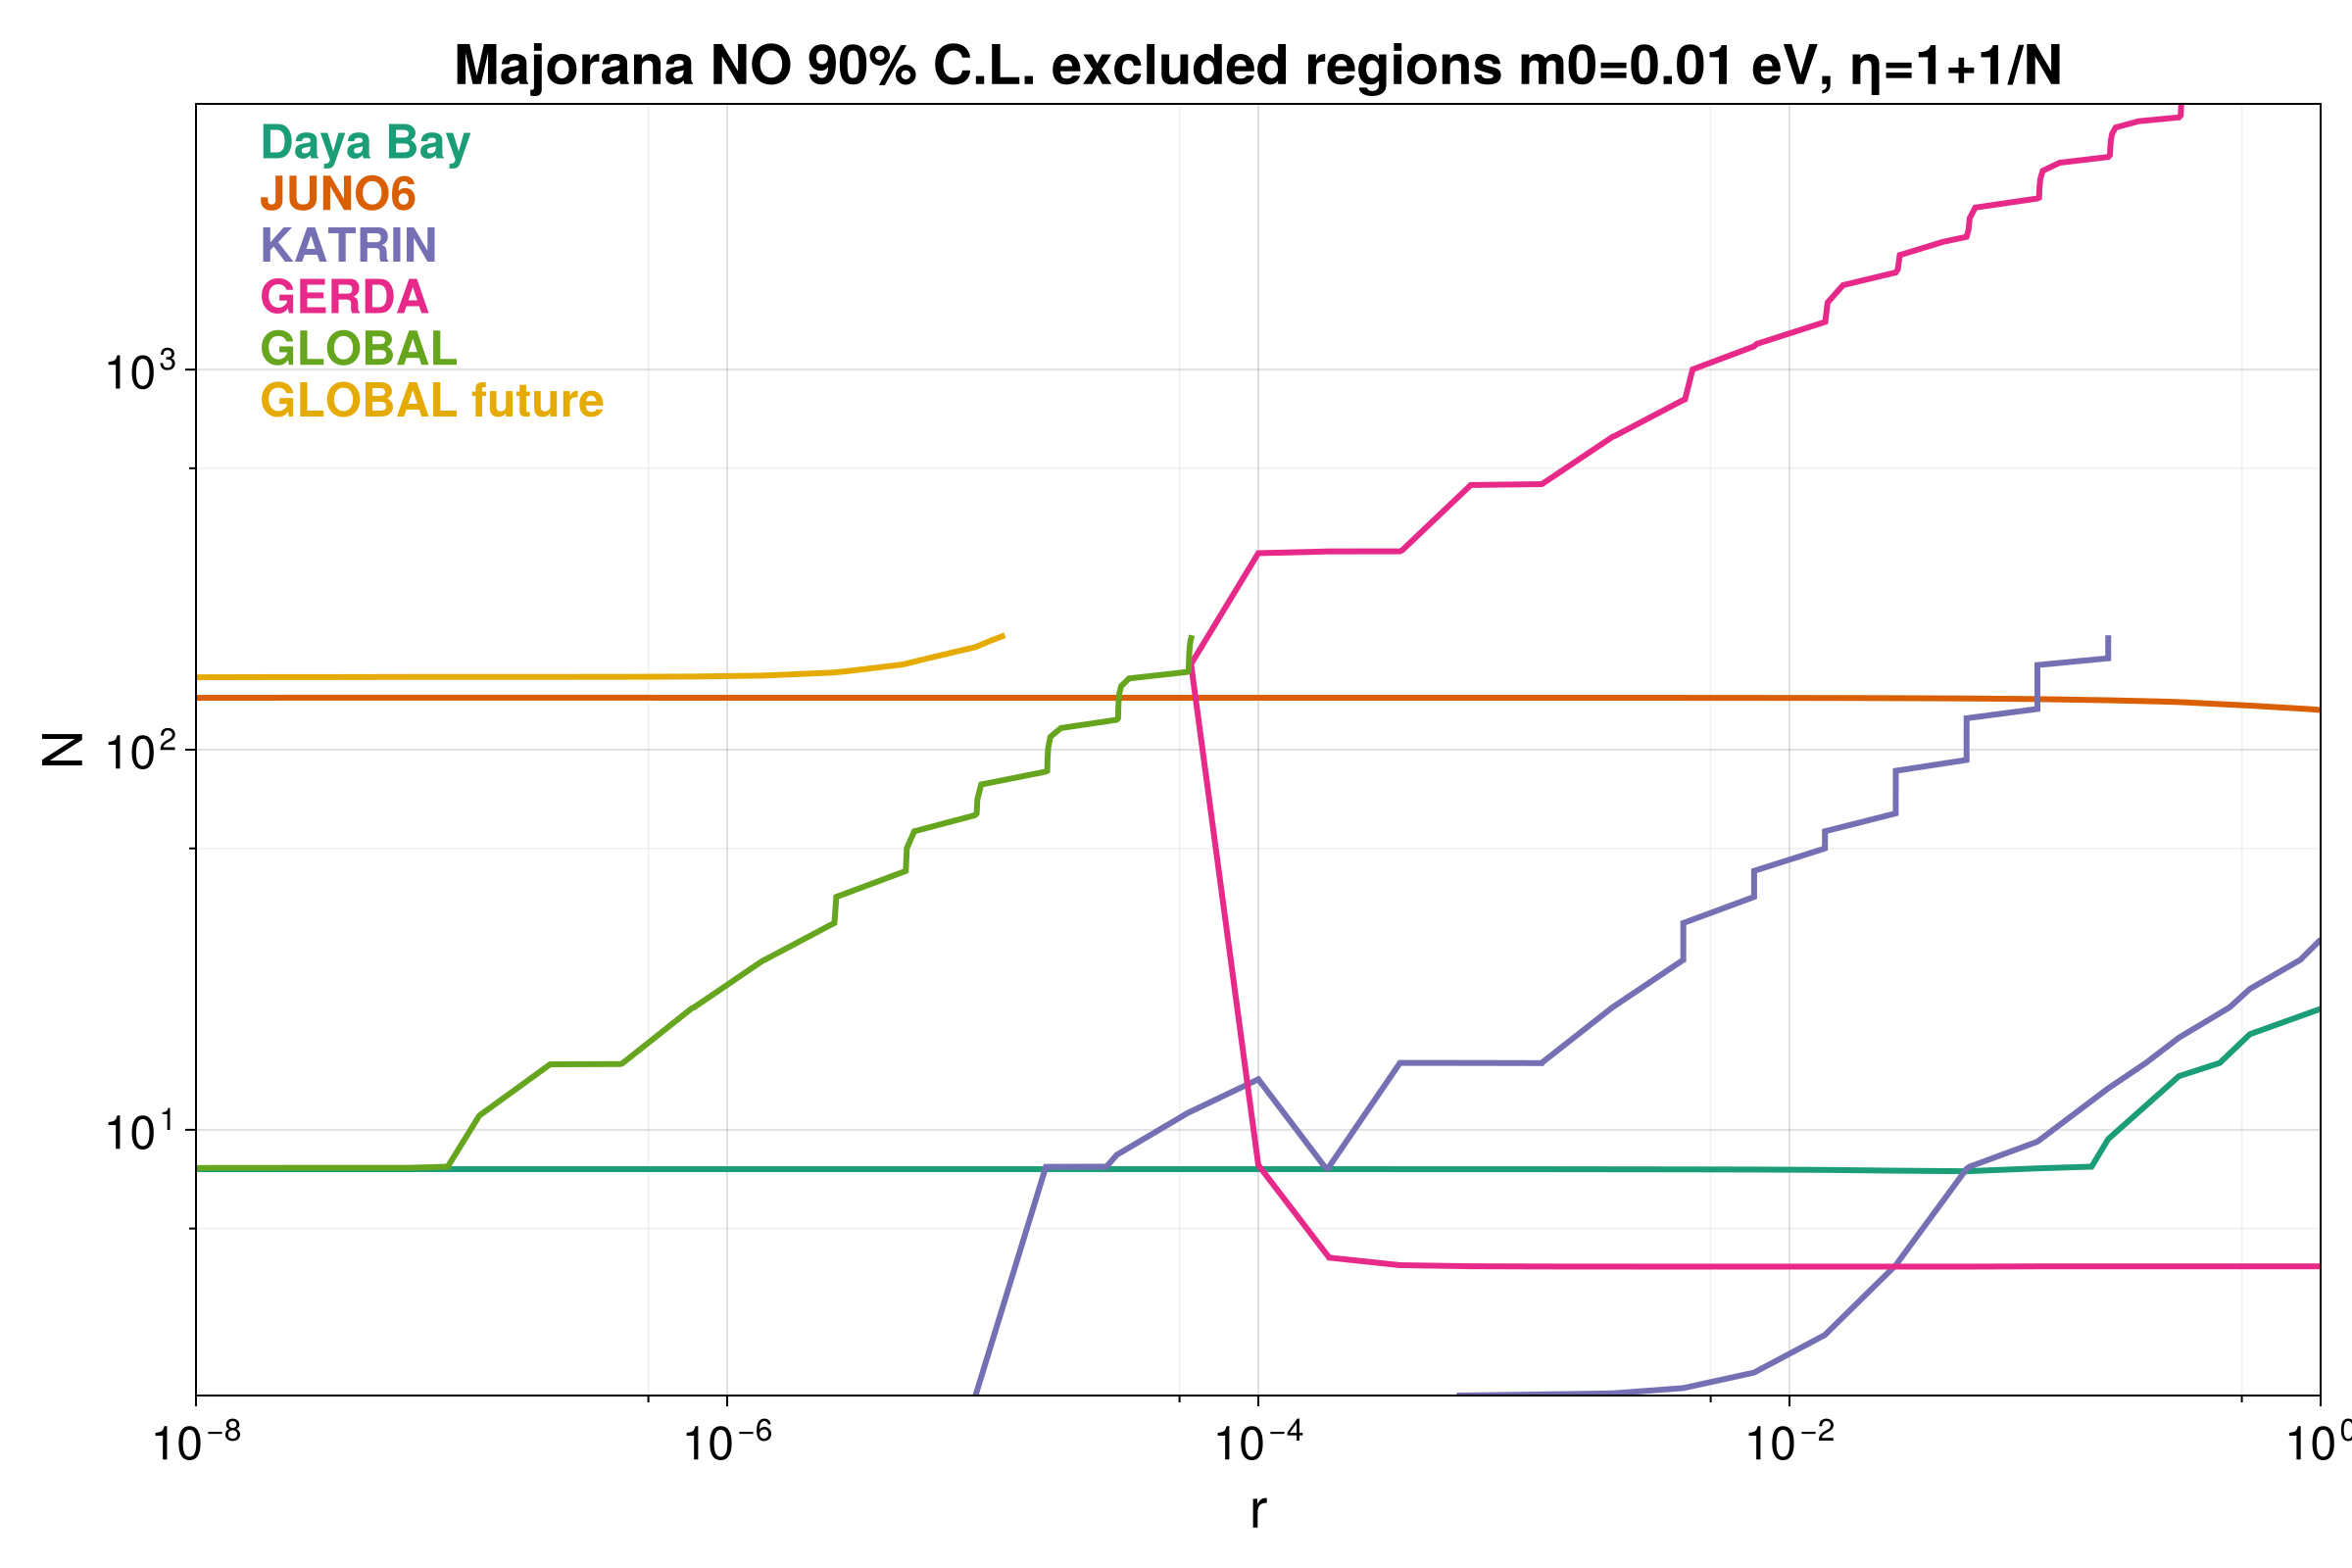

CairoMakie.Screen{IMAGE}


In [27]:
using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using Newtrinos

function superpose_contours(
    file_paths::Vector{String};
    title="Superposed Contours",
    experiments=nothing,
    colorscheme=:Dark2_8,
    color_step=1,
    linestyles=nothing,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing
)

    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]

    if length(colors) < length(file_paths)
        colors = [colors[i] for i in round.(Int,
            range(1, length(colors), length=length(file_paths)))]
    else
        colors = colors[1:length(file_paths)]
    end

    sigma_90 = quantile(Chisq(2), 0.90)

    results = []

    x_min = Inf
    x_max = -Inf
    y_min = Inf
    y_max = -Inf

    for fp in file_paths
        data = load(fp)
        result = only(values(data))

        push!(results, result)

        x_min = min(x_min, minimum(result.axes[1]))
        x_max = max(x_max, maximum(result.axes[1]))

        y_min = min(y_min, minimum(result.axes[2]))
        y_max = max(y_max, maximum(result.axes[2]))
    end

    axis_labels = collect(keys(results[1].axes))

    if xscale === identity && occursin("N", String(axis_labels[1]))
        xscale = log10
    end

    if yscale === identity && occursin("N", String(axis_labels[2]))
        yscale = log10
    end

    fig = Figure(size=(1200,800))

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = true,
        yminorgridvisible = true,
        titlesize = 28,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24
    )

    for (i,result) in enumerate(results)

        logp = result.values.log_posterior

        dLLH = 2 .* (maximum(logp) .- logp)

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH;
            levels = [sigma_90],
            color = colors[i],
            linewidth = 3,
            linestyle = linestyles[i]
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    if experiments !== nothing

        function pos(minv,maxv,f)

            if yscale == log10
                return 10^(log10(minv) + f*(log10(maxv)-log10(minv)))
            else
                return minv + f*(maxv-minv)
            end
        end

        ys = length(experiments)==1 ?
             [0.95] :
             collect(range(0.95,0.75,length=length(experiments)))

        xpos = pos(x_min,x_max,0.03)

        for (i,label) in enumerate(experiments)

            text!(
                ax,
                xpos,
                pos(y_min,y_max,ys[i]),
                text=label,
                color=colors[i],
                fontsize=24,
                font=:bold
            )
        end
    end

    return fig
end


file_paths = [
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_full6_rN_NNM_NO_η=1+1_N_m0=0.01_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/scan_final/scan_gerda_rN_m0_0.01_NNM_NO_5000.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/scan_global_data_rN_m0=0.01_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_rN_m0=0.01_NNM_NO (2).jld2"
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10,
   title="Majorana NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO6","KATRIN","GERDA","GLOBAL", "GLOBAL future"],
   
)

display(fig)

In [ ]:
using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering

function superpose_contours(
    file_paths::Vector{String};
    title="Superposed Contours",
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=0.6
)

    sigma_90 = quantile(Chisq(2), 0.90)

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        # works for both load(fp)["result"]
        # and only(values(load(fp)))
        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(1200,800))

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = true,
        yminorgridvisible = true,
        titlesize = 34,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 24,
        yticklabelsize = 24
    )

    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed =
            label in [  "JUNO6", "GLOBAL future"]

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=colors[i],
            linewidth=4.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    if experiments !== nothing

        legend_elements = LineElement[]
        legend_labels = String[]

        for (i,label) in enumerate(experiments)

            force_dashed =
                label in [ "JUNO6", "GLOBAL future"]

            push!(
                legend_elements,
                LineElement(
                    color=colors[i],
                    linewidth=4.5,
                    linestyle=force_dashed ? :dash : :solid
                )
            )

            push!(legend_labels, label)
        end

        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            tellwidth=false,
            tellheight=false,
            halign=:left,
            valign=:top,
            labelsize=22
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

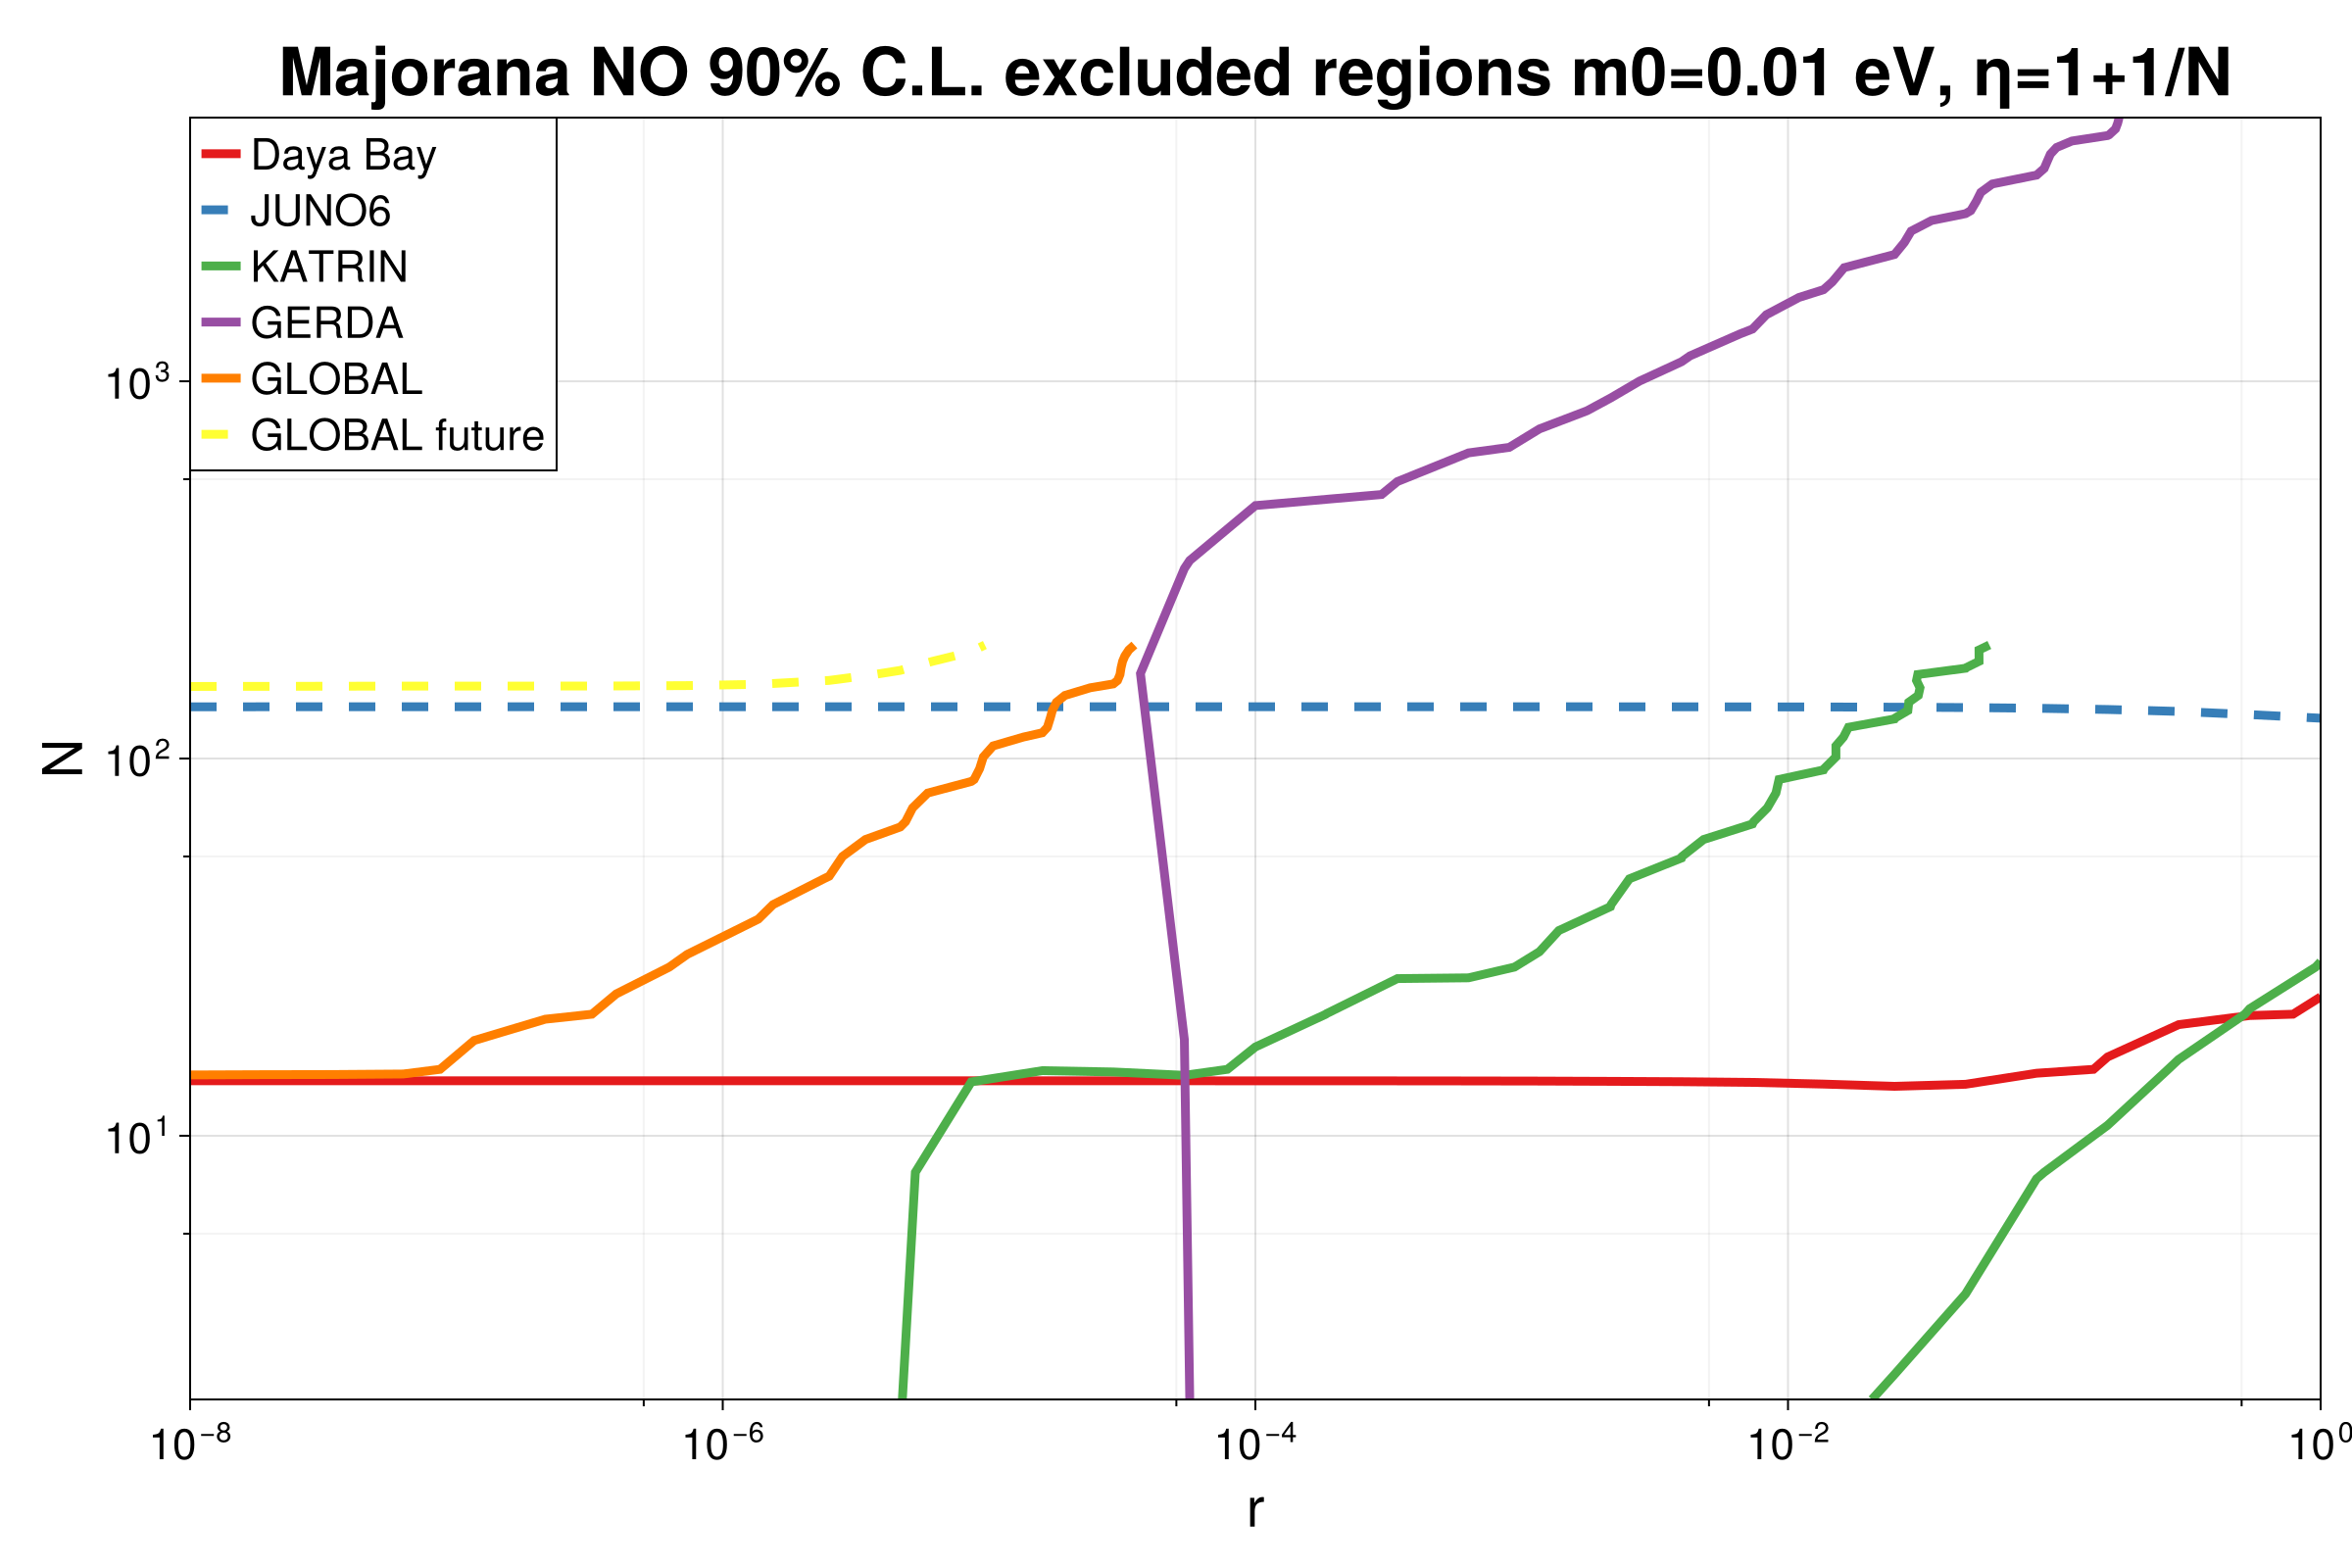

CairoMakie.Screen{IMAGE}


In [52]:

file_paths = [
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_full6_rN_NNM_NO_η=1+1_N_m0=0.01_log.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/scan_final/scan_gerda_rN_m0_0.01_NNM_NO_5000.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/junotao_m/scan_global_data_rN_m0=0.01_NNM_NO.jld2",
"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_rN_m0=0.01_NNM_NO (2).jld2"
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10,
   title="Majorana NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO6","KATRIN","GERDA","GLOBAL", "GLOBAL future"],
  
)

display(fig)